In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
df_apps = pd.read_csv('Google-Playstore.csv')
print('--- Apps Dataset Head ---')
display(df_apps.head())

--- Apps Dataset Head ---


,App Name,App Id,Category,Rating,Rating Count,Installs,Minimum Installs,Maximum Installs,Free,Price,...,Developer Website,Developer Email,Released,Last Updated,Content Rating,Privacy Policy,Ad Supported,In App Purchases,Editors Choice,Scraped Time
0,Gakondo,com.ishakwe.gakondo,Adventure,0.0,0.0,10+,10.0,15,True,0.0,...,https://beniyizibyose.tk/#/,jean21101999@gmail.com,"Feb 26, 2020","Feb 26, 2020",Everyone,https://beniyizibyose.tk/projects/,False,False,False,2021-06-15 20:19:35
1,Ampere Battery Info,com.webserveis.batteryinfo,Tools,4.4,64.0,"5,000+",5000.0,7662,True,0.0,...,https://webserveis.netlify.app/,webserveis@gmail.com,"May 21, 2020","May 06, 2021",Everyone,https://dev4phones.wordpress.com/licencia-de-uso/,True,False,False,2021-06-15 20:19:35
2,Vibook,com.doantiepvien.crm,Productivity,0.0,0.0,50+,50.0,58,True,0.0,...,NaN,vnacrewit@gmail.com,"Aug 9, 2019","Aug 19, 2019",Everyone,https://www.vietnamairlines.com/vn/en/terms-an...,False,False,False,2021-06-15 20:19:35
3,Smart City Trichy Public Service Vehicles 17UC...,cst.stJoseph.ug17ucs548,Communication,5.0,5.0,10+,10.0,19,True,0.0,...,http://www.climatesmarttech.com/,climatesmarttech2@gmail.com,"Sep 10, 2018","Oct 13, 2018",Everyone,NaN,True,False,False,2021-06-15 20:19:35
4,GROW.me,com.horodyski.grower,Tools,0.0,0.0,100+,100.0,478,True,0.0,...,http://www.horodyski.com.pl,rmilekhorodyski@gmail.com,"Feb 21, 2020","Nov 12, 2018",Everyone,http://www.horodyski.com.pl,False,False,False,2021-06-15 20:19:35


### **1. Dataset Loading & Inspection**
* **Data Ingestion:** Successfully loaded the `Google-Playstore.csv` dataset containing rich application metadata including app names, identifiers, categories, rating, and installation statistics.
* **Initial Structure Check:** Inspected initial rwos using `.head()` to verify dataset columns and data types for subsequent preprocessing.

In [2]:
df_apps.drop_duplicates(inplace=True)
if 'Minimum Installs' in df_apps.columns:
 df_apps['Minimum Installs'] = df_apps['Minimum Installs'].astype(str).str.replace('+', '', regex=False)
 df_apps['Minimum Installs'] = df_apps['Minimum Installs'].str.replace(',', '', regex=False).str.strip()
 df_apps['Minimum Installs'] = pd.to_numeric(df_apps['Minimum Installs'], errors='coerce')

if 'Price' in df_apps.columns:
    df_apps.dropna(subset=['Category', 'Rating', 'Minimum Installs'], inplace=True)
    print('Cleaned dataset shape:', df_apps.shape)

Cleaned dataset shape: (2290061, 24)


### **2. Data Cleaning & Preprocessing**
* **Duplicate Treatment:** Removed duplicate records to prevent data bias.
* **Feature Normalization:** Cleaned formatting symbols (`+`, `,`) from installation metrics (`Minimum Installs`) and converted numeric fields into proper data types.
* **Null Value Handling:** Filtered out records with missing essential parameters to maintain data cleanliness.

C:\Users\dell\AppData\Local\Temp\ipykernel_13920\3932740184.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_apps, y='Category', order=df_apps['Category'].value_counts().index[:15], palette='crest')


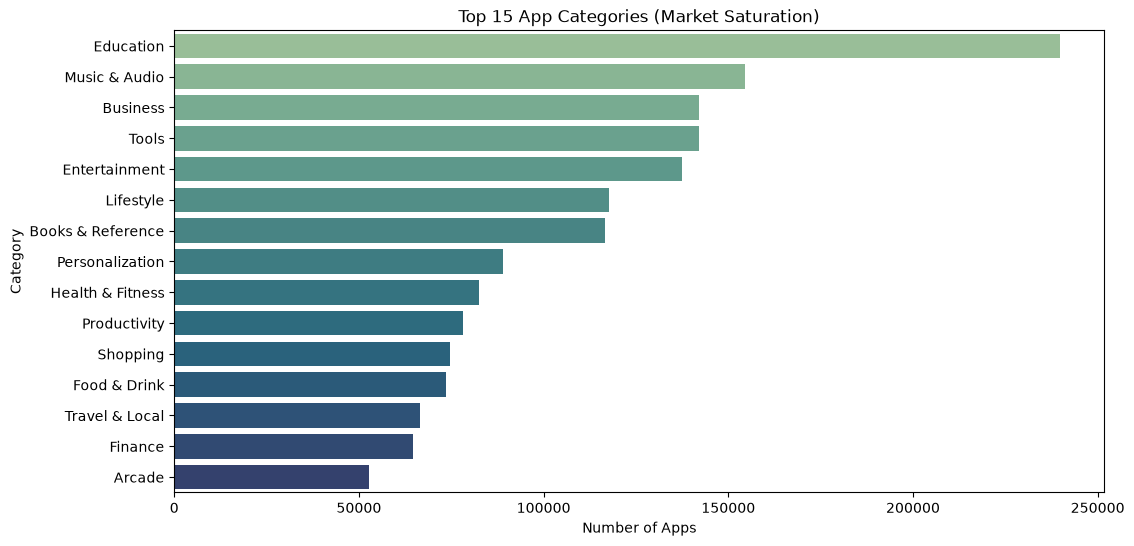

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.close('all')
plt.figure(figsize=(12, 6))
sns.countplot(data=df_apps, y='Category', order=df_apps['Category'].value_counts().index[:15], palette='crest')
plt.title('Top 15 App Categories (Market Saturation)')
plt.xlabel('Number of Apps')
plt.ylabel('Category')
plt.show()

### **3. Category Analysis & Market Saturation**
* **Distribution Count Plot:** Visualized app frequency across top categories using a horizontal count plot.
* **Saturation Insights:** Identified high-density categories to understand market competition levels.

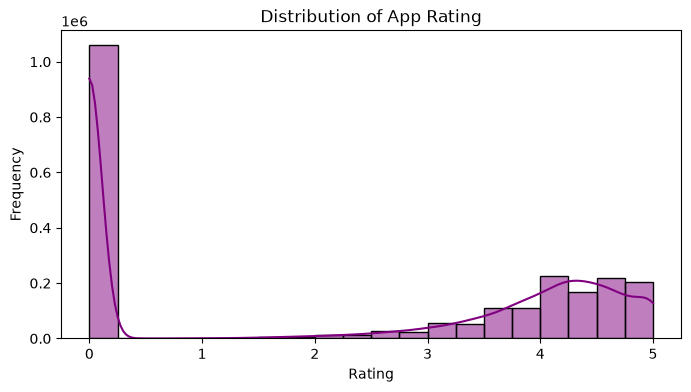

--- Top Categories by Average Rating ---


,Category,Rating
36,Role Playing,3.384498
10,Casino,3.279682
38,Simulation,3.210887
46,Weather,3.120295
9,Card,3.085160


In [5]:
plt.figure(figsize=(8, 4))
sns.histplot(df_apps['Rating'], bins=20, kde=True, color='purple')
plt.title('Distribution of App Rating')
plt.xlabel('Rating')
plt.ylabel('Frequency')
plt.show()

avg_rating = df_apps.groupby('Category')['Rating'].mean().reset_index()
print('--- Top Categories by Average Rating ---')
display(avg_rating.sort_values(by='Rating', ascending=False).head())

### **4. Rating Analysis**
* **Rating Distribution:** Plotted rating frequencies to analyze user satisfaction trends.
* **Category Aggregation:** Evaluated average scores grouped by category to highlight top-performing sectors.

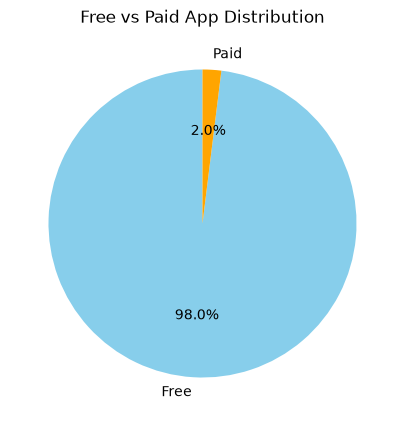

In [6]:
plt.figure(figsize=(5, 5))
df_apps['Free'].value_counts().plot.pie(autopct='%1.1f%%', labels=['Free', 'Paid'], colors=['skyblue', 'orange'], startangle=90)
plt.title('Free vs Paid App Distribution')
plt.ylabel('')
plt.show()

### **5. Pricing & Monetization Analysis**
* **Business Model Breakdown:** utilized the `Free` boolean column to analyze the market share proportion of free versus paid apps via a pie chart.

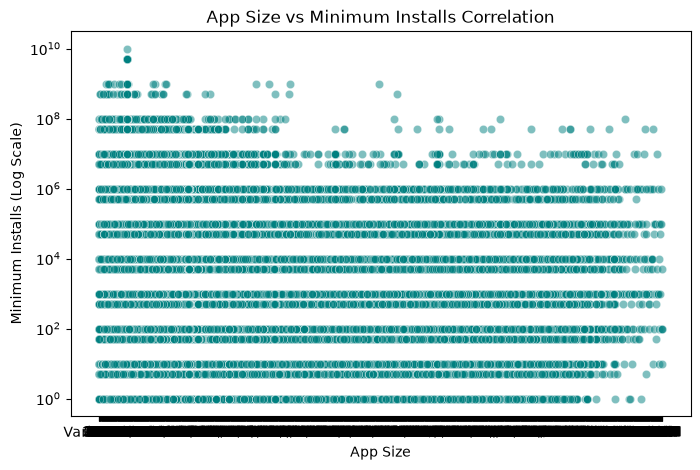

In [7]:
import matplotlib.pyplot as plt 
import seaborn as sns
plt.figure(figsize=(8, 5))
if 'Size' in df_apps.columns and'Minimum Installs' in df_apps.columns:
    sns.scatterplot(data=df_apps, x='Size', y='Minimum Installs', alpha=0.5, color='teal')
    plt.yscale('log')
    plt.title('App Size vs Minimum Installs Correlation')
    plt.xlabel('App Size')
    plt.ylabel('Minimum Installs (Log Scale)')
    plt.show()

### **6. Size and Installs Analysis**
* **Scatter Plot Generation:** Plotted application sizes against installation counts to check correlation trends.
* **Correaltion Insight:** Evaluated whether file size substantially affects user download choices.

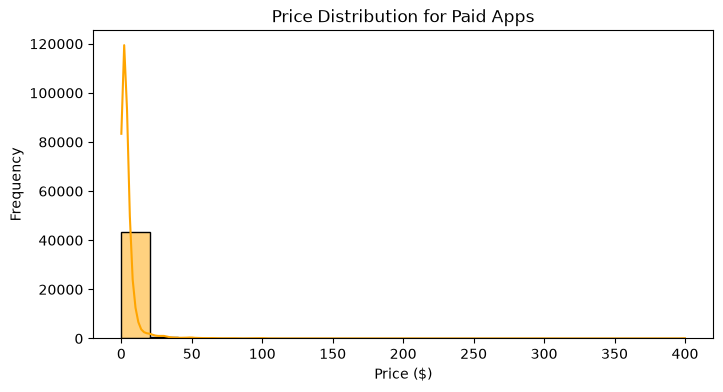

--- Top Revanue Categories ---


,Category,Estimated_Revanue
2,Arcade,1.291521e+08
0,Action,1.071133e+08
42,Tools,9.709852e+07
28,Music & Audio,8.673846e+07
36,Role Playing,8.350995e+07


In [8]:
paid_apps = df_apps[df_apps['Free'] == False]
if not paid_apps.empty:
    plt.figure(figsize=(8, 4))
    sns.histplot(paid_apps['Price'], bins=20, color='orange', kde=True)
    plt.title('Price Distribution for Paid Apps')
    plt.xlabel('Price ($)')
    plt.ylabel('Frequency')
    plt.show()

    if 'Price' in df_apps.columns and'Minimum Installs' in df_apps.columns:
        df_apps['Estimated_Revanue'] = df_apps['Price'] * df_apps['Minimum Installs']
        revanue_df = df_apps.groupby('Category')['Estimated_Revanue'].sum().reset_index()
        print('--- Top Revanue Categories ---')
        display(revanue_df.sort_values(by='Estimated_Revanue', ascending=False).head())

### **7. Detailed Pricing & Revanue Analysis**
* **Paid Price Distribution:** Analyzed price points of paid applications to understand standard pricing strategies.
* **Paid Price Distribution:** Calculated estimated financial returns per category by multiplying price with installation volumes.

In [10]:
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
df_reviews = pd.read_csv('googleplaystore_user_reviews.csv')
nltk.download('vader_lexicon', quiet=True)
sid = SentimentIntensityAnalyzer()
df_reviews_clean = df_reviews.dropna(subset=['Translated_Review']).copy()
df_reviews_clean['Compound'] = df_reviews_clean['Translated_Review'].apply(lambda x: sid.polarity_scores(str(x))['compound'])
def get_sentiment_label(score):
    if score >= 0.05:
       return 'Positive'
    elif score <= -0.05:
      return 'Negative'
    else:
       return 'Neutral'
df_reviews_clean['Sentiment_Label'] = df_reviews_clean['Compound'].apply(get_sentiment_label)
print('--- Review Sentiment Distribution ---')
print(df_reviews_clean['Sentiment_Label'].value_counts())

--- Review Sentiment Distribution ---
Sentiment_Label
Positive    25526
Negative     7505
Neutral      4396
Name: count, dtype: int64


### **8. Sentiment Analysis on User Reviews**
* **VADER Integration:** Utilized VADER lexicon polarity scoring to evaluate user reviews without model training overhead.
* **Sentiment Classification:** Successfully categories textual feedback into Positive, Negative, and Neutral classes.

In [11]:
merged_reviews = pd.merge(df_apps, df_reviews_clean, left_on='App Name', right_on='App', how='inner')
category_sentiment = pd.crosstab(merged_reviews['Category'], merged_reviews['Sentiment_Label'], normalize='index') * 100
print('--- Sentiment Percentage by Category ---')
display(category_sentiment.head())

--- Sentiment Percentage by Category ---


Sentiment_Label,Negative,Neutral,Positive
Category,,,
Action,21.509009,3.603604,74.887387
Adventure,12.649165,7.875895,79.474940
Arcade,17.413102,7.854278,74.732620
Art & Design,11.602210,11.602210,76.795580
Auto & Vehicles,5.333333,20.000000,74.666667


### **9.Sentiment by Category Analysis**
* **Cross-Tabulation:** Mapped user sentiments back to application categories to discover which sectors receive the highest percentage of positive feedback.

In [14]:
import plotly.express as px
fig = px.scatter(df_apps.head(300), x='Rating', y='Minimum Installs', color='Category', hover_name='App Name', title='Interactive Rating vs Installs')
fig.show()

### **10. Interactive Visualisation**
* **Plolty Dashboard Element:** Built an interactive scatter plot allowing dynamic hover-over inspection of application based on ratings and installs .

### **11. Conclusion & Strategic Developer Insights**
* **Free App Dominance:** the vast majority of application rely on a free-to-download ecosystem, meaning developers should target alternative monetization channels like ads or in-app purchases.
* **Competitive Saturation:** High-volume categories like Tools and family provide broad audiences but require distinctive featrue sets to overcome market seturation.
* **Rating & Sentiment Impact:** Maintaining high user satisfaction scores directly drives download velocity and long-term retention on the GOOgle Play Store.